# IT25102265 — Data Preprocessing & EDA (Fetal Health CTG)

**Student ID:** `IT25102265`  
**Email:** `it25102265@my.sliit.lk`  
**Module:** IT2011 Artificial Intelligence and Machine Learning  
**Notebook focus:** Median Imputation, IQR Row Removal, MaxAbs Scaling & Variance Threshold

### Important (Progress Review I)
This notebook covers **all required technique categories** (missing data, encoding, outliers, scaling, feature engineering/selection/dimension reduction) plus ≥3 EDA plots.
Method *choices inside each category* differ from other group members.

### Problem framing
Multiclass classification of fetal health from CTG features: **Normal (1)**, **Suspect (2)**, **Pathological (3)**.


## 0. Setup and paths


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, chi2, VarianceThreshold, SelectFromModel
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

ROOT = Path('..').resolve()
RAW_CSV = ROOT / 'data' / 'raw' / 'fetal_health.csv'
FIG_DIR = ROOT / 'results' / 'eda_visualizations' / 'IT25102265'
OUT_DIR = ROOT / 'results' / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'fetal_health'
CLASS_MAP = {1.0: 'Normal', 2.0: 'Suspect', 3.0: 'Pathological'}
RANDOM_STATE = 42
STUDENT_ID = 'IT25102265'

print('Student:', STUDENT_ID)
print('RAW_CSV exists:', RAW_CSV.exists())
print('Figures ->', FIG_DIR)


Student: IT25102265
RAW_CSV exists: True
Figures -> /home/neon-cultivator/us2/project-aiml/results/eda_visualizations/IT25102265


## 1. Load and understand the dataset

**What:** Load CTG data; inspect shape, dtypes, class balance.  
**Why:** Preprocessing choices must follow the real data profile.


In [2]:
df = pd.read_csv(RAW_CSV)
print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
display(df.head())
display(df.describe().T)
counts = df[TARGET].value_counts().sort_index()
print('\nTarget value counts:')
display(counts.rename(index=CLASS_MAP))
print('Class proportions (%):')
display((100 * counts / len(df)).round(2).rename(index=CLASS_MAP))


Shape: (2126, 22)

Dtypes:
 baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                       

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000



Target value counts:


fetal_health
Normal          1655
Suspect          295
Pathological     176
Name: count, dtype: int64

Class proportions (%):


fetal_health
Normal          77.85
Suspect         13.88
Pathological     8.28
Name: count, dtype: float64

**Interpretation:** Strong Normal-class dominance means later metrics should emphasise macro-F1 / per-class recall.


## 2. Handling missing data — Median imputation

**What:** Detect nulls; apply median imputation.  
**Why:** Median is robust when CTG distributions are skewed.


In [3]:
missing = df.isna().sum()
display(pd.DataFrame({'missing_count': missing, 'missing_pct': (100 * missing / len(df)).round(2)}))
print('Total missing cells:', int(df.isna().sum().sum()))
feature_cols = [c for c in df.columns if c != TARGET]
imputer = SimpleImputer(strategy='median')
imputed = imputer.fit_transform(df[feature_cols])
df_imputed = pd.DataFrame(imputed, columns=feature_cols, index=df.index)
df_imputed[TARGET] = df[TARGET].values
print('After median imputation — missing cells:', int(df_imputed.isna().sum().sum()))


,missing_count,missing_pct
baseline value,0,0.0
accelerations,0,0.0
fetal_movement,0,0.0
uterine_contractions,0,0.0
light_decelerations,0,0.0
severe_decelerations,0,0.0
prolongued_decelerations,0,0.0
abnormal_short_term_variability,0,0.0
mean_value_of_short_term_variability,0,0.0
percentage_of_time_with_abnormal_long_term_variability,0,0.0


Total missing cells: 0
After median imputation — missing cells: 0


**Interpretation:** Dataset has no missing values; median imputation keeps the technique explicit.


## 3. Duplicates and basic quality


In [4]:
n_dupes = df_imputed.duplicated().sum()
print('Exact duplicate rows:', int(n_dupes))
df_clean = df_imputed.drop_duplicates().copy()
print('Shape after dropping duplicates:', df_clean.shape)
print('Rows removed:', len(df_imputed) - len(df_clean))
feature_cols = [c for c in df_clean.columns if c != TARGET]


Exact duplicate rows: 13
Shape after dropping duplicates: (2113, 22)
Rows removed: 13


**Interpretation:** Exact duplicates are removed so repeated CTG rows do not inflate class counts.


## 4. Exploratory Data Analysis (≥3 visualizations)


### 4.1 Class distribution


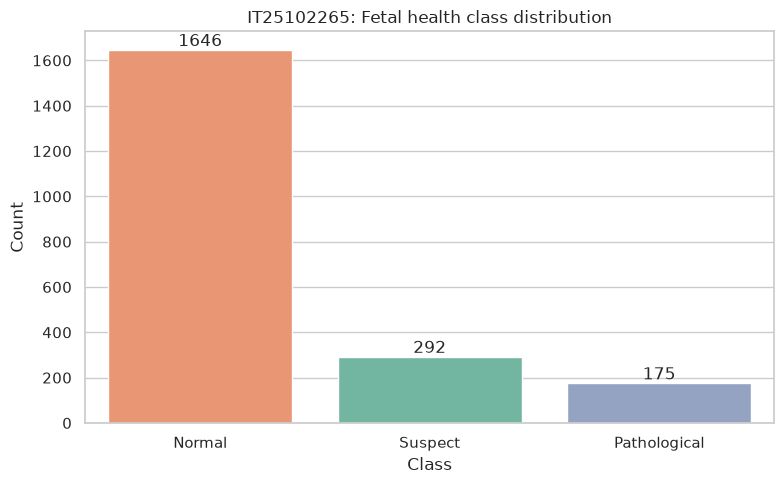

In [5]:
plot_df = df_clean.copy()
plot_df['class_name'] = plot_df[TARGET].map(CLASS_MAP)
order = ['Normal', 'Suspect', 'Pathological']
fig, ax = plt.subplots()
sns.countplot(data=plot_df, x='class_name', order=order, hue='class_name', palette='Set2', legend=False, ax=ax)
ax.set_title(f'{STUDENT_ID}: Fetal health class distribution')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Normal dominates; minority Suspect/Pathological classes need careful evaluation later.


### 4.2 Boxplots by class


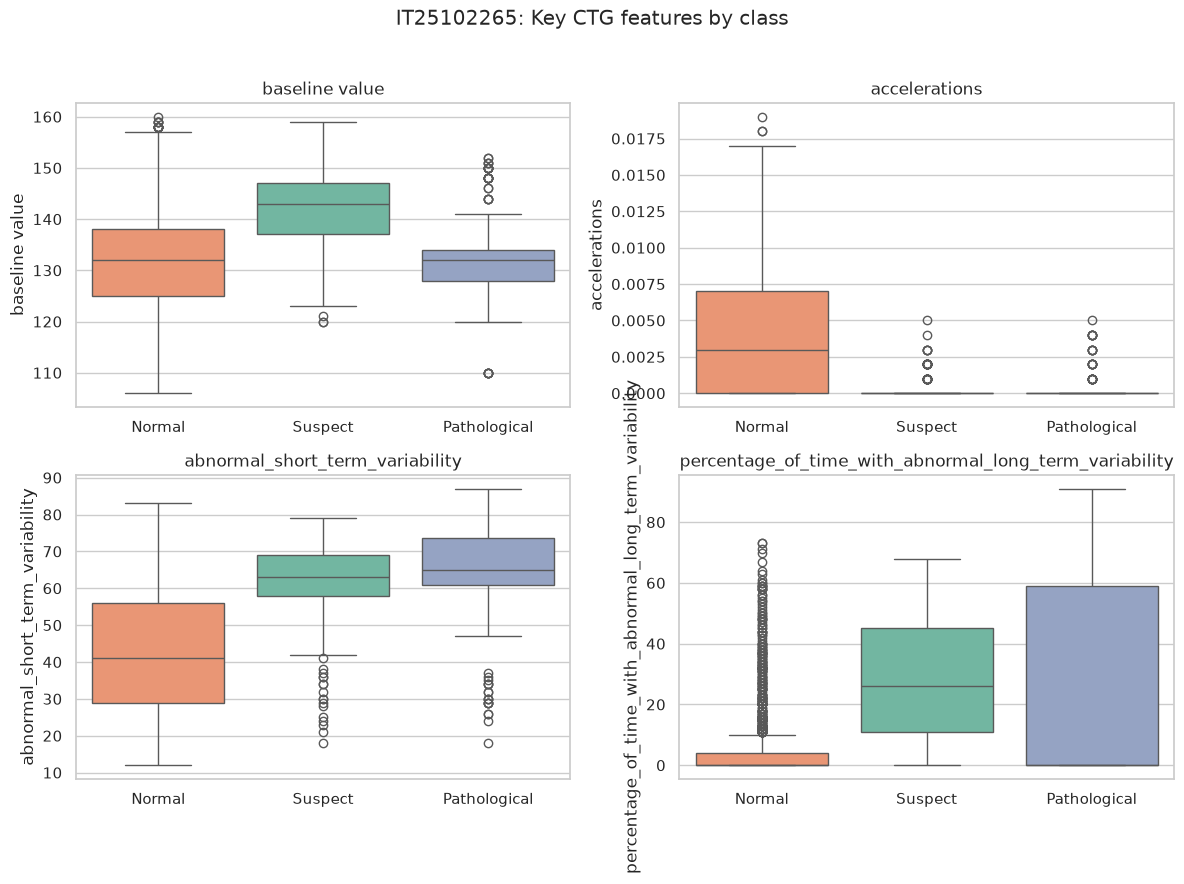

In [6]:
box_features = [
    'baseline value', 'accelerations',
    'abnormal_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), box_features):
    sns.boxplot(data=plot_df, x='class_name', y=col, order=order, hue='class_name', palette='Set2', legend=False, ax=ax)
    ax.set_title(col); ax.set_xlabel('')
fig.suptitle(f'{STUDENT_ID}: Key CTG features by class', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Variability and acceleration patterns differ across health classes.


### 4.3 Correlation heatmap


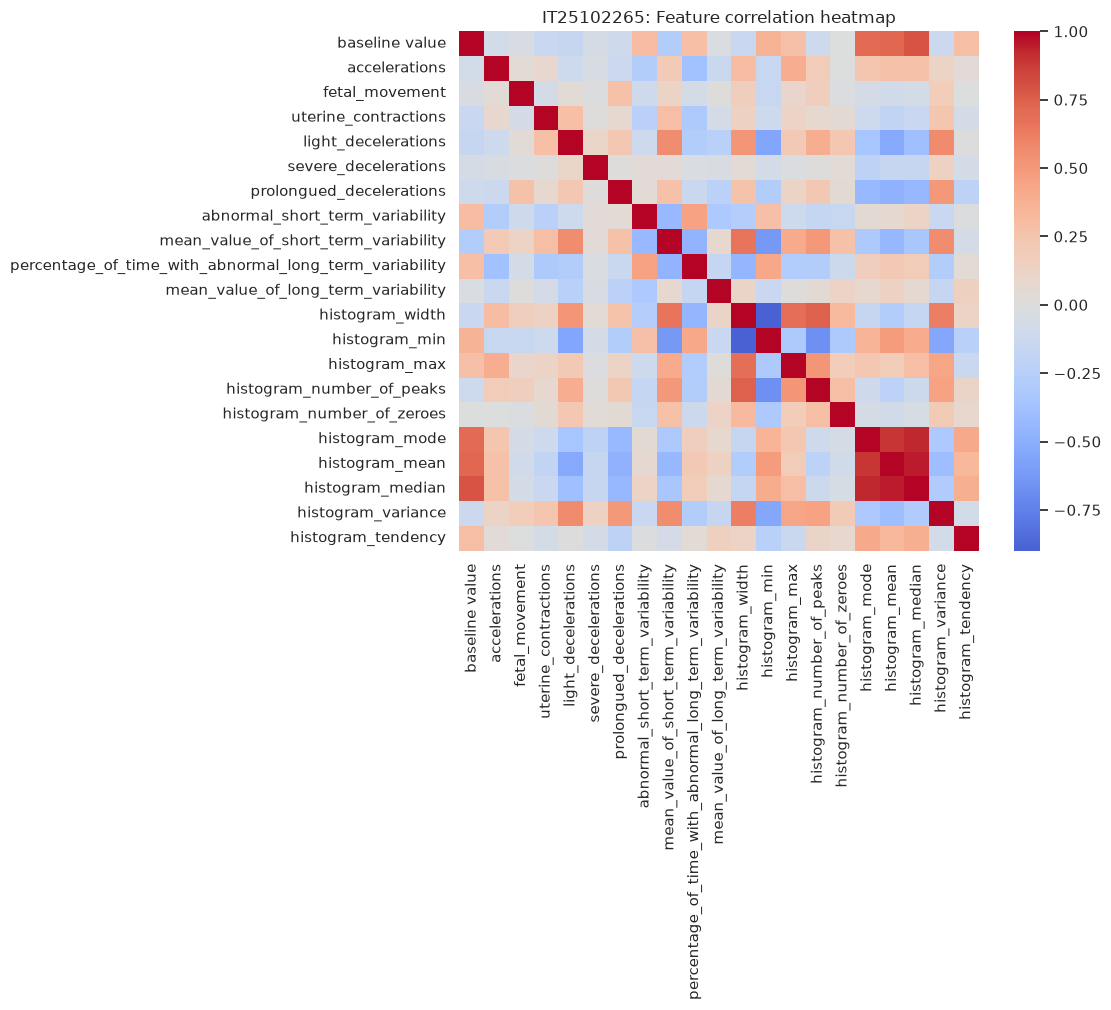

Top 10 |correlation| pairs:


histogram_mean   histogram_median             0.948077
histogram_mode   histogram_median             0.933166
histogram_width  histogram_min                0.899054
histogram_mode   histogram_mean               0.893083
baseline value   histogram_median             0.788487
histogram_width  histogram_number_of_peaks    0.746894
baseline value   histogram_mean               0.722152
                 histogram_mode               0.708074
histogram_width  histogram_max                0.692645
histogram_min    histogram_number_of_peaks    0.670410
dtype: float64

In [7]:
corr = df_clean[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title(f'{STUDENT_ID}: Feature correlation heatmap')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().abs().sort_values(ascending=False)
print('Top 10 |correlation| pairs:')
display(corr_pairs.head(10))


**Interpretation:** Histogram features are highly correlated → selection / dimension reduction is justified.


## 5. Outlier handling — IQR row removal (Pathological protected)

**What:** Remove IQR outlier rows on selected features, but keep Pathological rows.  
**Why:** Demonstrates removal while limiting harm to the rare critical class.


In [8]:
df_out = df_clean.copy()
watch = [
    'percentage_of_time_with_abnormal_long_term_variability',
    'abnormal_short_term_variability', 'histogram_variance', 'accelerations',
]
mask_any = pd.Series(False, index=df_out.index)
report = []
for col in watch:
    q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    col_mask = (df_out[col] < lower) | (df_out[col] > upper)
    report.append({'feature': col, 'n_outliers': int(col_mask.sum())})
    mask_any = mask_any | col_mask
display(pd.DataFrame(report))
before = len(df_out)
keep = (~mask_any) | (df_out[TARGET] == 3.0)
df_out = df_out.loc[keep].copy()
print(f'Rows before={before}, after={len(df_out)}, removed={before - len(df_out)}')
display(df_out[TARGET].value_counts().sort_index().rename(index=CLASS_MAP))


,feature,n_outliers
0,percentage_of_time_with_abnormal_long_term_var...,305
1,abnormal_short_term_variability,0
2,histogram_variance,184
3,accelerations,14


Rows before=2113, after=1731, removed=382


fetal_health
Normal          1417
Suspect          139
Pathological     175
Name: count, dtype: int64

**Interpretation:** Outlier treatment documents the clinical trade-off between noise reduction and minority-class preservation.


## 6. Encoding — get_dummies on tendency + LabelEncoder target

**What:** Dummy-encode tendency; LabelEncoder for modelling target.  
**Why:** Transparent pandas encoding for EDA and linear baselines.


In [9]:
df_enc = df_out.copy()
df_enc['tendency_cat'] = pd.Categorical(df_enc['histogram_tendency'])
dummies = pd.get_dummies(df_enc['tendency_cat'], prefix='tend', dtype=float)
df_enc = pd.concat([df_enc, dummies], axis=1)
label_encoder = LabelEncoder()
df_enc['fetal_health_encoded'] = label_encoder.fit_transform(df_enc[TARGET].astype(int))
print('Dummy columns:', list(dummies.columns))
display(df_enc[['histogram_tendency'] + list(dummies.columns)].head())
extra_enc_cols = list(dummies.columns)


Dummy columns: ['tend_-1.0', 'tend_0.0', 'tend_1.0']


,histogram_tendency,tend_-1.0,tend_0.0,tend_1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0
5,0.0,0.0,1.0,0.0


**Interpretation:** Encoding makes categorical/ordinal fields explicit for sklearn estimators.


## 7–8. Scaling (MaxAbsScaler), feature engineering, selection, dimension reduction


,count,mean,std,min,25%,50%,75%,max
severe_share,1731.0,0.000544,0.012916,0.0,0.0,0.0,0.0,0.49975
prolongued_flag,1731.0,0.083189,0.276247,0.0,0.0,0.0,0.0,1.00000
abn_var_product,1731.0,330.211438,982.144951,0.0,0.0,0.0,218.5,7371.00000
baseline_dev,1731.0,10.041017,7.121736,0.0,4.0,8.0,15.0,34.00000


Scaler: MaxAbsScaler
Scaled mean sample: {'baseline value': 0.8281, 'accelerations': 0.2258, 'fetal_movement': 0.0195}
VarianceThreshold kept 17 features
[np.str_('accelerations'), np.str_('uterine_contractions'), np.str_('light_decelerations'), np.str_('prolongued_decelerations'), np.str_('abnormal_short_term_variability'), np.str_('mean_value_of_short_term_variability'), np.str_('percentage_of_time_with_abnormal_long_term_variability'), np.str_('mean_value_of_long_term_variability'), np.str_('histogram_width'), np.str_('histogram_min'), np.str_('histogram_number_of_peaks'), np.str_('tend_-1.0'), np.str_('tend_0.0'), np.str_('tend_1.0'), np.str_('prolongued_flag'), np.str_('abn_var_product'), np.str_('baseline_dev')]
PCA components for target variance: 9
Cumulative variance: 0.9327


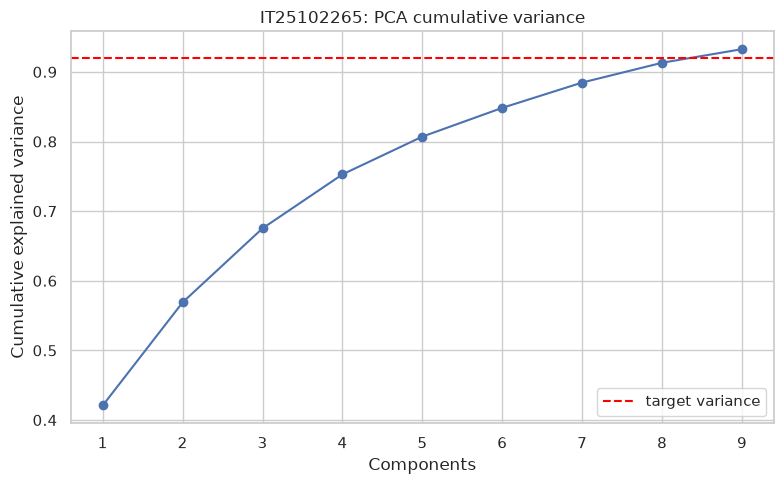

In [10]:
df_fe = df_enc.copy()
eps = 1e-6
df_fe['severe_share'] = df_fe['severe_decelerations'] / (df_fe['light_decelerations'] + df_fe['severe_decelerations'] + df_fe['prolongued_decelerations'] + eps)
df_fe['prolongued_flag'] = (df_fe['prolongued_decelerations'] > 0).astype(float)
df_fe['abn_var_product'] = df_fe['abnormal_short_term_variability'] * df_fe['percentage_of_time_with_abnormal_long_term_variability']
df_fe['baseline_dev'] = (df_fe['baseline value'] - 140.0).abs()
engineered = ['severe_share', 'prolongued_flag', 'abn_var_product', 'baseline_dev']

display(df_fe[engineered].describe().T)

base_cols = [c for c in feature_cols if c != 'histogram_tendency']

X_fe_cols = base_cols + extra_enc_cols + engineered

seen = set(); X_fe_cols = [c for c in X_fe_cols if not (c in seen or seen.add(c))]

X_fe_cols = [c for c in X_fe_cols if c in df_fe.columns]

X_all = df_fe[X_fe_cols].astype(float).copy()

y_all = df_fe['fetal_health_encoded'].copy()

scaler = MaxAbsScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=X_fe_cols, index=X_all.index)

print('Scaler:', type(scaler).__name__)

print('Scaled mean sample:', X_scaled.mean().head(3).round(4).to_dict())

vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_scaled)
selected_features = list(np.array(X_fe_cols)[vt.get_support()])
print('VarianceThreshold kept', len(selected_features), 'features')
print(selected_features)
X_selected_df = pd.DataFrame(X_vt, columns=selected_features, index=X_scaled.index)

pca = PCA(n_components=0.92, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('PCA components for target variance:', pca.n_components_)
print('Cumulative variance:', round(pca.explained_variance_ratio_.sum(), 4))
fig, ax = plt.subplots()
cum = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cum)+1), cum, marker='o')
ax.axhline(0.92, color='red', linestyle='--', label='target variance')
ax.set_title(f'{STUDENT_ID}: PCA cumulative variance')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative explained variance')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '04_pca_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Engineered CTG features + selection remove redundancy; PCA/SVD compress correlated signal.


## 9. Export processed dataset


In [11]:
processed = df_fe[X_fe_cols + [TARGET, 'fetal_health_encoded']].copy()
out_path = OUT_DIR / f'{STUDENT_ID}_fetal_health_processed.csv'
processed.to_csv(out_path, index=False)
print('Saved:', out_path)
print('Processed shape:', processed.shape)
display(processed.head())


Saved: /home/neon-cultivator/us2/project-aiml/results/outputs/IT25102265_fetal_health_processed.csv
Processed shape: (1731, 29)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_variance,tend_-1.0,tend_0.0,tend_1.0,severe_share,prolongued_flag,abn_var_product,baseline_dev,fetal_health,fetal_health_encoded
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,...,12.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,1.0,0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,...,13.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,1.0,0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,...,13.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,1.0,0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,...,11.0,0.0,0.0,1.0,0.0,0.0,0.0,8.0,1.0,0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,...,170.0,0.0,1.0,0.0,0.0,1.0,0.0,6.0,3.0,2


## 10. Bridge — stratified split + baseline (no leakage)

Fit imputer/scaler on **train only**. Baseline Logistic Regression with `class_weight='balanced'`.


Train: (1384, 27) Test: (347, 27)


Accuracy=0.8876 | Macro-F1=0.8035


              precision    recall  f1-score   support

      Normal       0.98      0.89      0.93       284
     Suspect       0.44      0.86      0.58        28
Pathological       0.91      0.89      0.90        35

    accuracy                           0.89       347
   macro avg       0.78      0.88      0.80       347
weighted avg       0.93      0.89      0.90       347



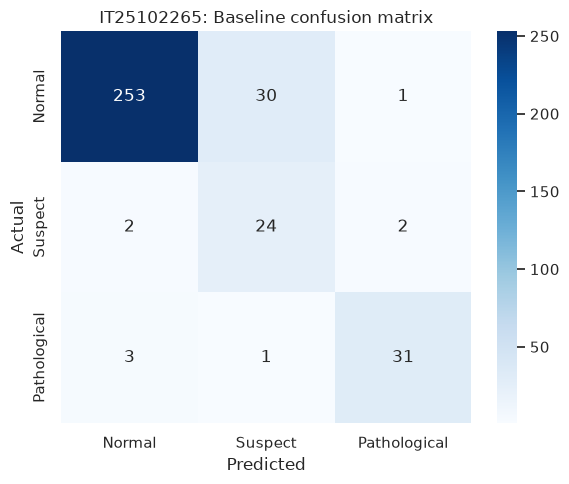

In [12]:
X = df_fe[X_fe_cols].astype(float).copy()
y = df_fe['fetal_health_encoded'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
pipe_imputer = SimpleImputer(strategy='median')
pipe_scaler = StandardScaler()
X_train_s = pipe_scaler.fit_transform(pipe_imputer.fit_transform(X_train))
X_test_s = pipe_scaler.transform(pipe_imputer.transform(X_test))
baseline = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
baseline.fit(X_train_s, y_train)
y_pred = baseline.predict(X_test_s)
print(f"Accuracy={accuracy_score(y_test, y_pred):.4f} | Macro-F1={f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred, target_names=[CLASS_MAP[float(c)] for c in label_encoder.classes_]))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
labels = [CLASS_MAP[float(c)] for c in label_encoder.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'{STUDENT_ID}: Baseline confusion matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
